# **HPDP Assignment 2: Mastering Big Data Handling**
Evelyn Goh Yuan Qi (A23CS0222)

Lim Yu Han (A23CS0241)

In [ ]:
import pandas as pd
import numpy as np
import os
import dask.dataframe as dd
from IPython.display import display
import psutil
import time
import csv
import polars as pl
import pyarrow.parquet as pq
import pyarrow.compute as pc
import threading
import json
import gc
import tracemalloc

**A. Load and Inspect Data**

---

 **Upload Method: Kaggle API**

Step1: Upload kaggle.json (the API key)

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yyuhan","key":"ac6790a17e841eb418b9c04d85826d21"}'}

Step2: Configure Kaggle to move kaggle.json to the right location

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Step3: Download only part-01.json

In [ ]:
!kaggle datasets download -d ebiswas/imdb-review-dataset -f part-01.json

Dataset URL: https://www.kaggle.com/datasets/ebiswas/imdb-review-dataset
License(s): CC0-1.0
100% 379M/379M [00:10<00:00, 37.5MB/s]



Step4: Unzip the file

In [ ]:
!unzip part-01.json.zip

Archive:  part-01.json.zip
  inflating: part-01.json            


Step5: Verify the file

In [ ]:
!ls -lh

total 1.4G
-rw-r--r-- 1 root root   62 May  9 16:50 kaggle.json
-rw-r--r-- 1 root root 1.1G Jan 11  2021 part-01.json
-rw-r--r-- 1 root root 379M Jan 11  2021 part-01.json.zip
drwxr-xr-x 1 root root 4.0K May  6 13:29 sample_data


Step6: Understanding the data

In [ ]:
# 1. Load data
df = pd.read_json('part-01.json')
df.to_json("part-01.json", orient="records", lines=True)

# 2. Shape
print("Dataset shape")
print(f"- Rows: {df.shape[0]:,}")
print(f"- Columns: {df.shape[1]}")

# 3. Column names and its data type
print("\nColumn names and data types:")
display(df.dtypes.to_frame(name='Data Type'))

# 4. Missing values
print("\nMissing values")
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    for col in missing_cols:
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        print(f"- {col}: {null_count:,} missing ({null_pct:.1f}%)")
else:
    print("No missing values found")

# 5. First 5 records
print("\nFirst 5 rows")
display(df.head())

Dataset shape
- Rows: 1,010,293
- Columns: 9

Column names and data types:


,Data Type
review_id,object
reviewer,object
movie,object
rating,float64
review_summary,object
review_date,object
spoiler_tag,int64
review_detail,object
helpful,object



Missing values
- rating: 51,520 missing (5.1%)

First 5 rows


,review_id,reviewer,movie,rating,review_summary,review_date,spoiler_tag,review_detail,helpful
0,rw5704482,raeldor-96879,After Life (2019– ),9.0,Very Strong Season 2,3 May 2020,0,"I enjoyed the first season, but I must say I t...","[1, 1]"
1,rw5704483,dosleeb,The Valhalla Murders (2019– ),6.0,Icelandic detectives?,3 May 2020,0,I know Iceland is a small country and police d...,"[2, 2]"
2,rw5704484,brightconscious,Special OPS (2020– ),7.0,Nothing special,3 May 2020,0,"Except K K , no other actor looks comfortable ...","[0, 0]"
3,rw5704485,gasconyway,#BlackAF (2020– ),8.0,Good but,3 May 2020,0,I'm guessing that as a 62 year old white woman...,"[5, 9]"
4,rw5704487,mmason-15867,The Droving (2020),2.0,An honest review,3 May 2020,0,Here's the truth. There's not much to this mov...,"[26, 41]"


**B. Big Data Handling Strategies**

---

Performance Measurement Function

In [ ]:
def measure_performance(func, description=""):
    # 1. Preparation
    process = psutil.Process(os.getpid())

    # 2. Baseline Snapshots
    ram_start = process.memory_info().rss / (1024 * 1024)
    start_time = time.time()

    # 3. Execute Strategy
    result = func()

    # 4. End Snapshots
    end_time = time.time()
    ram_end = process.memory_info().rss / (1024 * 1024)

    # 5. Metrics Calculation
    duration = round(end_time - start_time, 2)
    memory_used = round(ram_end - ram_start, 2)

    row_count = len(result) if hasattr(result, '__len__') else 0
    throughput = round(row_count / duration, 2) if duration > 0 else 0

    return {
        'Strategy': description,
        'Memory (MB)': memory_used,
        'Time (sec)': duration,
        'Rows Processed': row_count,
        'Throughput (rows/sec)': throughput
    }, result

**Strategy 1: Load Less Data**

Instead of loading all 9 columns, load only the columns needed for analysis.

In [ ]:
def load_less_data():
    column_to_use = ['review_id', 'movie', 'rating', 'spoiler_tag', 'review_date']
    df = pd.read_json('part-01.json', lines=True)[column_to_use]
    return df

performance1, df_less = measure_performance(load_less_data, "Load Less Data")

print(performance1)
display(df_less.head())

{'Strategy': 'Load Less Data', 'Memory (MB)': 2472.43, 'Time (sec)': 17.14, 'Rows Processed': 1010293, 'Throughput (rows/sec)': 58943.58}


,review_id,movie,rating,spoiler_tag,review_date
0,rw5704482,After Life (2019– ),9.0,0,3 May 2020
1,rw5704483,The Valhalla Murders (2019– ),6.0,0,3 May 2020
2,rw5704484,Special OPS (2020– ),7.0,0,3 May 2020
3,rw5704485,#BlackAF (2020– ),8.0,0,3 May 2020
4,rw5704487,The Droving (2020),2.0,0,3 May 2020


**Strategy 2: Chunking**

Process the file in smaller chunks instead of loading everything into memory at once.

In [ ]:
# Chunking reads files in segments so the whole file never hits RAM
def chunking():
    df = pd.read_json("part-01.json", lines=True, chunksize=100000)

    chunk_results = []
    for i, chunk in enumerate(df):
        # Calculate average review length
        avg_text_len = chunk['review_detail'].str.len().mean()
        chunk_results.append(avg_text_len)

        if (i + 1) % 5 == 0:
            print(f"Processed {i+1} chunks...")

    return pd.Series(chunk_results)

performance2, df_chunk = measure_performance(chunking, "Chunking")
print(performance2)

Processed 5 chunks...
Processed 10 chunks...
{'Strategy': 'Chunking', 'Memory (MB)': 0.5, 'Time (sec)': 19.18, 'Rows Processed': 11, 'Throughput (rows/sec)': 0.57}


**Strategy 3: Data Type Optimisation**

Pandas often uses excessive memory so we downcast types to reduce memory footprint.

In [ ]:
def data_type_optimization():
    df = pd.read_json('part-01.json', lines=True)

    mem_before = df.memory_usage(deep=True).sum() / (1024**2)

    # Optimise data types
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce').astype('float32')
    df['spoiler_tag'] = df['spoiler_tag'].astype('int8')
    df['movie'] = df['movie'].astype('category')
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

    mem_after = df.memory_usage(deep=True).sum() / (1024**2)

    print(f"Memory before: {mem_before:.1f} MB")
    print(f"Memory after : {mem_after:.1f} MB")
    print(f"Memory reduction: {((mem_before - mem_after)/mem_before)*100:.1f}%")

    return df

performance3, df_type = measure_performance(data_type_optimization, "Data Type Optimisation")
print(df_type.info())
print(performance3)

Memory before: 1322.2 MB
Memory after : 1200.4 MB
Memory reduction: 9.2%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010293 entries, 0 to 1010292
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   review_id       1010293 non-null  object        
 1   reviewer        1010293 non-null  object        
 2   movie           1010293 non-null  category      
 3   rating          958773 non-null   float32       
 4   review_summary  1010293 non-null  object        
 5   review_date     1010293 non-null  datetime64[ns]
 6   spoiler_tag     1010293 non-null  int8          
 7   review_detail   1010293 non-null  object        
 8   helpful         1010293 non-null  object        
dtypes: category(1), datetime64[ns](1), float32(1), int8(1), object(5)
memory usage: 60.2+ MB
None
{'Strategy': 'Data Type Optimisation', 'Memory (MB)': 826.41, 'Time (sec)': 23.07, 'Rows Processed': 1010293, 'Throughput 

**Strategy 4: Sampling**

Use a representative sample for fast prototyping and exploration before running on full data.

In [ ]:
def sampling():
    df = pd.read_json('part-01.json', lines=True).sample(frac=0.1, random_state=42)

    avg_rating = df['rating'].mean()
    print(f"Average rating in sample: {avg_rating:.2f}")
    return df

performance4, df_sample = measure_performance(sampling, "Sampling")
print(performance4)

Average rating in sample: 6.70
{'Strategy': 'Sampling', 'Memory (MB)': 1349.3, 'Time (sec)': 16.92, 'Rows Processed': 101029, 'Throughput (rows/sec)': 5970.98}


**Strategy 5: Parallel Processing with Polars**

Use Polars to process data in parallel with lazy evaluation for faster and more efficient handling of large datasets.

In [ ]:
def parallel_with_polars():
    df = pl.read_ndjson("part-01.json")

    result = (
        df.select(["rating", "spoiler_tag"])
        .with_columns(pl.col("rating").cast(pl.Float32))
        .group_by("spoiler_tag")
        .agg(pl.col("rating").mean().alias("avg_rating"))
    )

    return result

performance5, polars_parallel_result = measure_performance(
    parallel_with_polars,
    "Parallel Processing with Polars"
)

print(performance5)

{'Strategy': 'Parallel Processing with Polars', 'Memory (MB)': 1092.09, 'Time (sec)': 4.2, 'Rows Processed': 2, 'Throughput (rows/sec)': 0.48}


**C. Data Processing Performance Across Libraries**

---

In this section, the same operation is performed across Pandas, Polars, and PyArrow, which involves loading the dataset, selecting the "rating" column, and calculating the average "rating" to evaluate their behaviour on large data.

In [ ]:
import polars as pl

df = pl.read_ndjson("part-01.json")
df.write_parquet("part-01.parquet")

1. Pandas

In [ ]:
def pandas_performance():
    df = pd.read_parquet("part-01.parquet", columns=["rating"])
    df["rating"] = df["rating"].astype("float32")
    result = df["rating"].mean()
    return result

pandas_perf, pandas_result = measure_performance(pandas_performance, "Pandas")
print("Average Rating: ", pandas_result)
print(pandas_perf)

Average Rating:  6.704052
{'Strategy': 'Pandas', 'Memory (MB)': 25.46, 'Time (sec)': 0.31, 'Rows Processed': 0, 'Throughput (rows/sec)': 0.0}


2. Polars

In [ ]:
def polars_performance():
    df = pl.read_parquet("part-01.parquet", columns=["rating"])
    result = df.select(pl.col("rating").cast(pl.Float32).mean())
    return result

polars_perf, polars_result = measure_performance(polars_performance, "Polars")
print("Average Rating: ", polars_result)
print(polars_perf)

Average Rating:  shape: (1, 1)
┌──────────┐
│ rating   │
│ ---      │
│ f32      │
╞══════════╡
│ 6.704052 │
└──────────┘
{'Strategy': 'Polars', 'Memory (MB)': 9.8, 'Time (sec)': 0.1, 'Rows Processed': 1, 'Throughput (rows/sec)': 10.0}


3. PyArrow

In [ ]:
def pyarrow_performance():
    table = pq.read_table("part-01.parquet", columns=["rating"])

    # Convert rating from string to float
    rating_float = pc.cast(table["rating"], "float32", safe=False)

    result = pc.mean(rating_float)
    return result

pyarrow_perf, pyarrow_result = measure_performance(pyarrow_performance, "PyArrow")
print("Average Rating: ", pyarrow_result)
print(pyarrow_perf)

Average Rating:  6.704051949731584
{'Strategy': 'PyArrow', 'Memory (MB)': 7.3, 'Time (sec)': 0.12, 'Rows Processed': 0, 'Throughput (rows/sec)': 0.0}


**D. Comparative Analysis**

---

**Part A: Comparison of Big Data Handling Strategies**


=== Strategy Comparison Table ===


,Strategy,Execution Time (s),Memory Usage (MB)
0,Load Less Data,17.14,2472.43
1,Chunking,19.18,0.50
2,Data Type Optimisation,23.07,826.41
3,Sampling,16.92,1349.30
4,Parallel Processing (Polars),4.20,1092.09


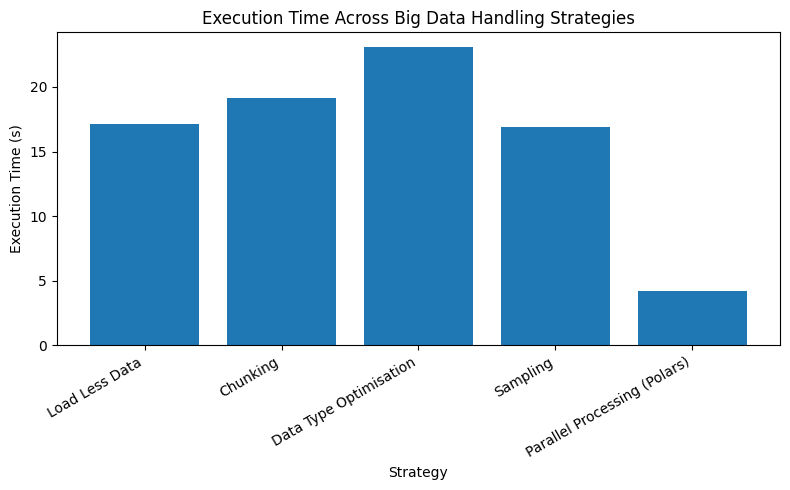

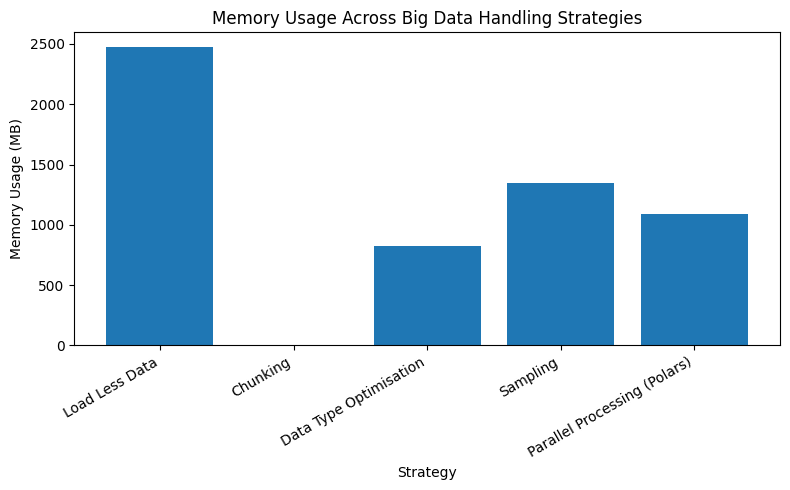

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all strategy performance
strategy_results = [
    performance1,
    performance2,
    performance3,
    performance4,
    performance5
]

# Convert to DataFrame
strategy_df = pd.DataFrame(strategy_results)

# Rename for clarity
strategy_df["Strategy"] = [
    "Load Less Data",
    "Chunking",
    "Data Type Optimisation",
    "Sampling",
    "Parallel Processing (Polars)"
]

# Rename columns
strategy_df = strategy_df.rename(columns={
    "Time (sec)": "Execution Time (s)",
    "Memory (MB)": "Memory Usage (MB)"
})

strategy_df = strategy_df[[
    "Strategy",
    "Execution Time (s)",
    "Memory Usage (MB)"
]]

# -------- TABLE --------
print("=== Strategy Comparison Table ===")
display(strategy_df)

# -------- EXECUTION TIME CHART --------
plt.figure(figsize=(8,5))
plt.bar(strategy_df["Strategy"], strategy_df["Execution Time (s)"])

plt.xlabel("Strategy")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time Across Big Data Handling Strategies")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -------- MEMORY USAGE CHART --------
plt.figure(figsize=(8,5))
plt.bar(strategy_df["Strategy"], strategy_df["Memory Usage (MB)"])

plt.xlabel("Strategy")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Across Big Data Handling Strategies")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Part B: Comparison Across Libraries**

,Library,Execution Time (s),Memory Usage (MB)
0,Pandas,0.31,25.46
1,Polars,0.10,9.80
2,PyArrow,0.12,7.30


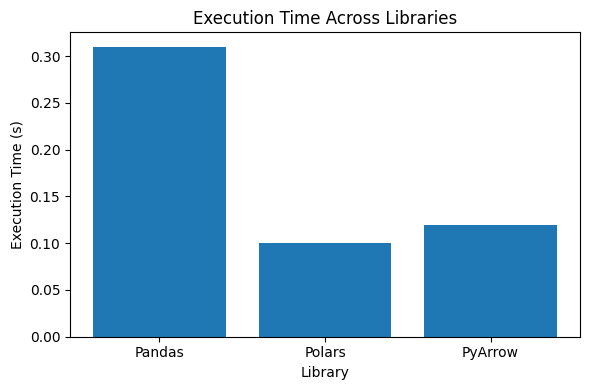

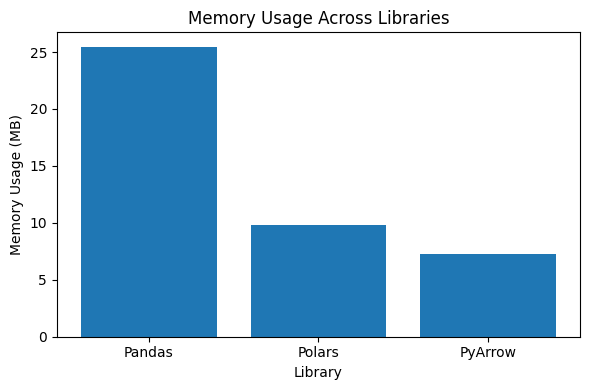

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

library_results = [
    pandas_perf,
    polars_perf,
    pyarrow_perf
]

library_df = pd.DataFrame(library_results)

# Rename column for this section
library_df = library_df.rename(columns={
    "Strategy": "Library",
    "Time (sec)": "Execution Time (s)",
    "Memory (MB)": "Memory Usage (MB)"
})

library_df = library_df[[
    "Library",
    "Execution Time (s)",
    "Memory Usage (MB)"
]]

display(library_df)

# Execution Time Chart
plt.figure(figsize=(6,4))
plt.bar(library_df["Library"], library_df["Execution Time (s)"])
plt.xlabel("Library")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time Across Libraries")
plt.tight_layout()
plt.show()

# Memory Usage Chart
plt.figure(figsize=(6,4))
plt.bar(library_df["Library"], library_df["Memory Usage (MB)"])
plt.xlabel("Library")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Across Libraries")
plt.tight_layout()
plt.show()